In [6]:
import importlib
from hamilton import driver
from pathlib import Path

from ivr_utils import ivr_utils, cityseg_utils

import logging

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)


In [7]:
# Use this to reload the module after making changes to it.
importlib.reload(ivr_utils)
importlib.reload(cityseg_utils)
dr = driver.Builder().with_modules(ivr_utils, cityseg_utils).with_cache().build()

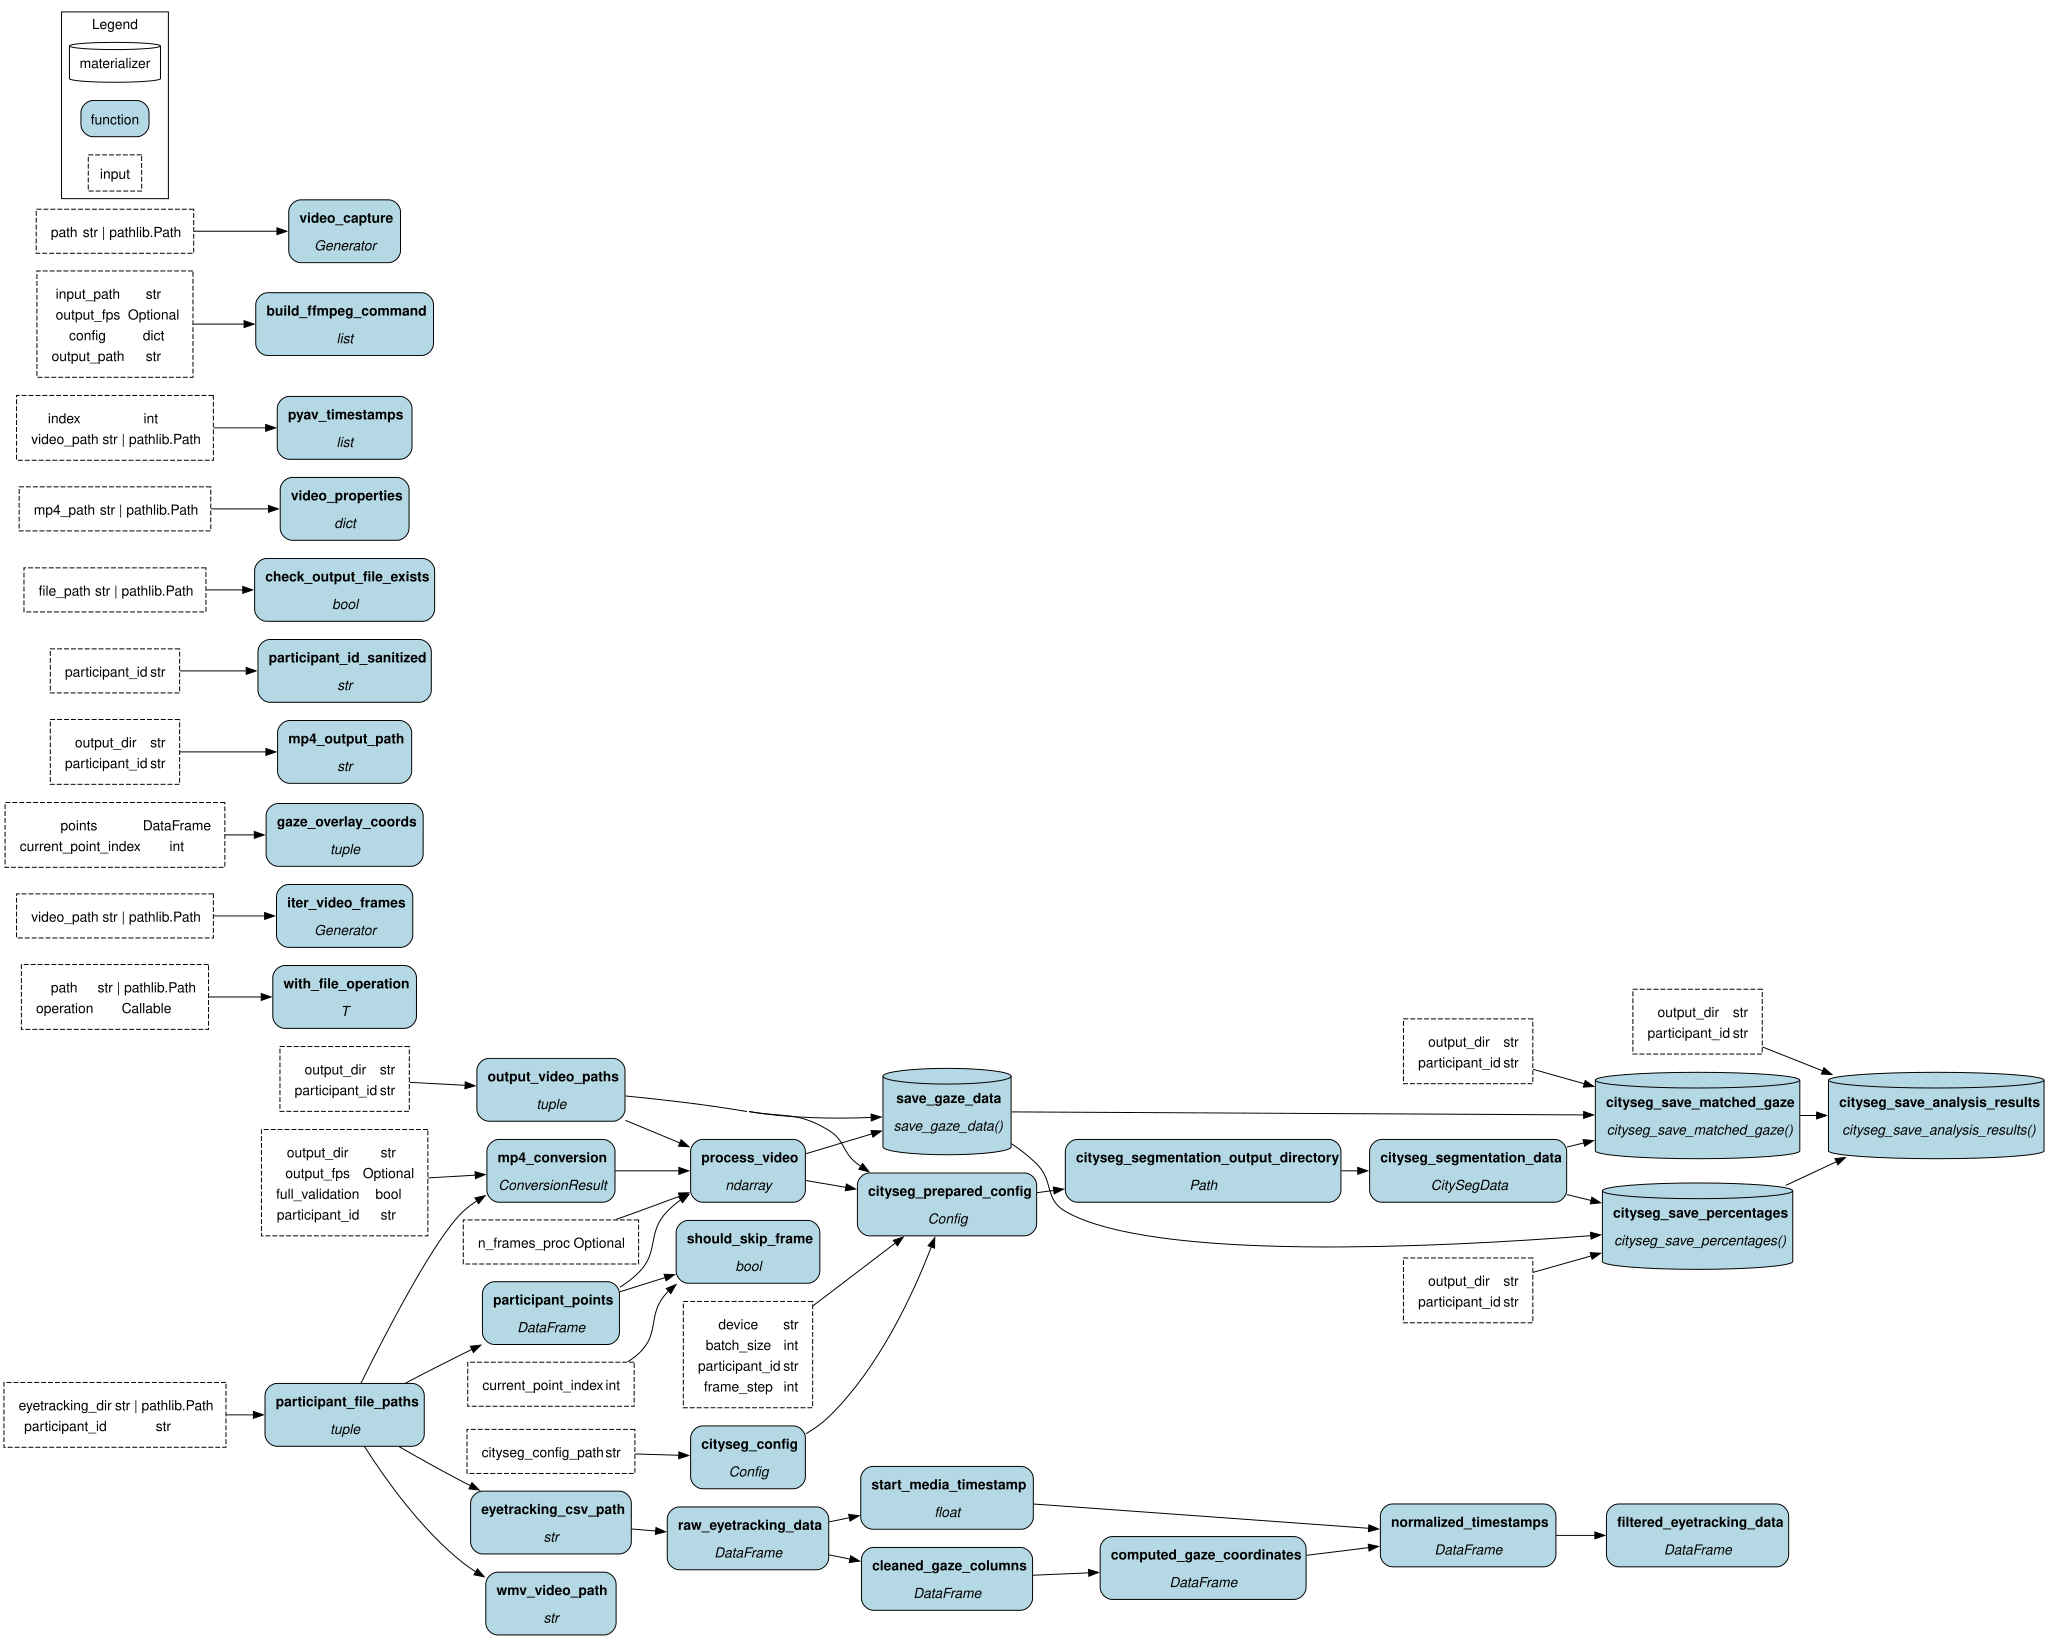

In [8]:
# Define final variables to compute - including CitySeg processing
final_vars = [
    "mp4_conversion",
    "output_video_paths",
    "save_gaze_data",
    "cityseg_save_analysis_results",  # Terminal node for CitySeg processing
]

# Define inputs - including CitySeg configuration
inputs = {
    "participant_id": "P43",
    "n_frames_proc": None,
    "eyetracking_dir": "/Volumes/ritd-ag-project-rd01wq-tober63/SSID IVR Study 1/Eyetracking",
    "output_dir": "/Users/mitch/Documents/UCL/Papers_2025/SSID_IVR_Study/data/output/2025-04-15-test",
    "cityseg_config_path": "/Users/mitch/Documents/UCL/Papers_2025/SSID_IVR_Study/cityseg_configs/andrew_config.yaml",
    "frame_step": 15,  # Process every 15th frame
    "batch_size": 5,  # Process 5 frames at a time
    "device": "mps",  # For M2 Mac
}

dr.display_all_functions()

# Visualize the execution graph
# dr.visualize_execution(
#     final_vars,
#     inputs=inputs,
#     output_file_path="graph_with_cityseg.png",
#     bypass_validation=True,
# )

In [ ]:
from pprint import pprint

pprint(dr.cache.logs(level="info"))


In [ ]:
# Execute the pipeline
res = dr.execute(final_vars, inputs=inputs)

In [ ]:
# View the execution results
dr.cache.view_run(run_id=dr.cache.last_run_id)